# USD/KRW 월말 네고 효과: 언제 강해지는가

수출업체의 월말 달러 매도(네고)가 환율에 남기는 흔적을 확인하고, 그 효과가 어떤 조건에서 강해지는지 가설을 세워 검증한다. OTMKU 세션 발표용으로 정리한 분석이다.

1. 데이터 점검
2. 기본 효과
3. 가설 6개 검증
4. 전략 백테스트
5. 외부 변수로 다시 검증하고 전략을 고친다

쓰는 자료는 서울외국환중개(SMBS) USD/KRW 일별 시세, KRX 미국달러선물 최근월물, 한국은행 기준금리 변경 이력이고, 5장에서 DXY, USD/JPY, 한미 금리, KOSPI, S&P500, VIX, WTI를 더한다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

sns.set_style("whitegrid")
MAIN = "#1B5E5C"     # OTM 발표자료 색
SUB = "#4C9F8B"
RED = "#C00000"
GRAY = "#A6A6A6"

## 1. 데이터 점검

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
raw = pd.read_excel("/content/drive/MyDrive/Quant/SMBS_USDKRW_19990202_20260522.xlsx")
fut_raw = pd.read_csv("/content/drive/MyDrive/Quant/달러선물_최근월물_통합_1999_2026.csv")
rate_table = pd.read_excel("/content/drive/MyDrive/Quant/korea_base_rate_history.xlsx")

raw["날짜"] = pd.to_datetime(raw["날짜"])
fut_raw["날짜"] = pd.to_datetime(fut_raw["날짜"])
print(len(raw), len(fut_raw), len(rate_table))

7113 6686 61


### 종가가 비어 있는 날

SMBS 파일의 `15:30 종가`는 SMBS를 통해 체결된 거래의 종가라서, 체결이 없던 날은 0으로 들어와 있다. 연도별로 세어 보면 2001년과 2002년에 몰려 있다. 같은 날 `환율`(매매기준율) 열은 정상이므로 시장이 닫힌 게 아니라 이 중개사에 체결이 없었던 것이다.

2002년과 2019~2023년에는 종가만 있고 시가와 거래량이 0인 날이 하나씩 있다. 연말 마지막 날처럼 거래가 없던 날이라 거래일에서 뺀다.

In [ ]:
has_close = raw["15:30 종가"] > 0
has_open = raw["시가"] > 0
weekday = raw["날짜"].dt.weekday < 5

check = pd.DataFrame({
    "평일 행": weekday.groupby(raw["날짜"].dt.year).sum(),
    "종가 있음": (weekday & has_close).groupby(raw["날짜"].dt.year).sum(),
    "종가만 있고 시가 없음": (has_close & ~has_open).groupby(raw["날짜"].dt.year).sum(),
})
check["종가 없는 평일"] = check["평일 행"] - check["종가 있음"]
check[(check["종가 없는 평일"] > 15) | (check["종가만 있고 시가 없음"] > 0)]

,평일 행,종가 있음,종가만 있고 시가 없음,종가 없는 평일
날짜,,,,
2001,247,135,0,112
2002,245,109,1,136
2019,247,247,1,0
2020,249,249,1,0
2021,249,249,1,0
2022,247,247,1,0
2023,246,246,1,0


In [ ]:
raw[(raw["날짜"] >= "2001-05-08") & (raw["날짜"] <= "2001-05-17")][["날짜", "환율", "시가", "15:30 종가", "당사 거래량(Mio)"]]

,날짜,환율,시가,15:30 종가,당사 거래량(Mio)
668,2001-05-08,1302.2,0.0,0.0,0.0
669,2001-05-09,1298.1,0.0,0.0,0.0
670,2001-05-10,1303.6,0.0,0.0,0.0
671,2001-05-11,1306.2,0.0,0.0,0.0
672,2001-05-12,1301.7,0.0,0.0,0.0
673,2001-05-14,1301.7,1297.5,1297.5,1.0
674,2001-05-15,1297.4,0.0,0.0,0.0
675,2001-05-16,1304.0,0.0,0.0,0.0
676,2001-05-17,1307.2,1302.8,1300.6,13.5


### 선물과 맞춰 보기

같은 날의 달러선물 종가와 비교하면 현물 종가가 믿을 만한지 알 수 있다. 차이의 중앙값은 0.1원, 사분위 범위는 -0.5~0.9원이다.

크게 벌어진 날은 2008~2011년의 급변동일이다. 2008년 10월 30일에는 현물이 177원(12.4%) 내렸는데 선물은 가격제한폭에 걸려 5%만 내렸다. 현물 값이 틀린 것이 아니라 선물이 따라가지 못한 날이다. 2010년 9월 20일처럼 선물 쪽이 튀는 날도 있지만 현물 분석에는 영향이 없다.

In [ ]:
spot = raw[has_close & has_open].set_index("날짜")
fut = fut_raw.set_index("날짜")

basis_won = (fut["종가"] - spot["15:30 종가"]).dropna()
print("선물 종가 - 현물 종가 (원)")
print(basis_won.describe().round(2).to_string())
print("\n차이가 15원을 넘는 날")
gap = pd.DataFrame({"현물 종가": spot["15:30 종가"], "선물 종가": fut["종가"]}).dropna()
gap["차이"] = gap["선물 종가"] - gap["현물 종가"]
print(gap[gap["차이"].abs() > 15].round(1).to_string())

선물 종가 - 현물 종가 (원)
count    6438.00
mean        0.15
std         2.56
min       -70.90
25%        -0.50
50%         0.10
75%         0.90
max       103.30

차이가 15원을 넘는 날
             현물 종가   선물 종가     차이
날짜                               
2008-09-16  1160.0  1143.5  -16.5
2008-10-07  1328.1  1293.8  -34.3
2008-10-08  1395.0  1332.6  -62.4
2008-10-16  1373.0  1302.1  -70.9
2008-10-30  1250.0  1353.3  103.3
2008-12-15  1367.0  1346.0  -21.0
2008-12-30  1259.5  1302.0   42.5
2009-02-16  1427.5  1408.5  -19.0
2010-05-25  1250.0  1269.0   19.0
2010-09-20  1161.3  1212.0   50.7
2010-12-20  1150.2  1166.8   16.6
2011-09-19  1137.0  1116.5  -20.5
2011-09-22  1179.8  1198.0   18.2


### 기준금리 표

2018-04-20에 2.00%로 올린 것으로 돼 있는 행은 실제 결정에 없다. 2017년 11월 1.50%에서 2018년 11월 1.75%로 바로 이어지므로 이 행은 뺐다.

In [ ]:
# 기준금리 표: 2018-04-20 2.00%는 실제 금통위 결정에 없는 행이라 뺀다 (2017-11 1.50% -> 2018-11 1.75%)
rate_table = rate_table.rename(columns={"변경일자": "date", "기준금리(%)": "rate"})
rate_table["date"] = pd.to_datetime(rate_table["date"])
rate_table = rate_table[rate_table["date"] != "2018-04-20"].sort_values("date").reset_index(drop=True)
rate_table.tail(10)

,date,rate
50,2022-05-26,1.75
51,2022-07-13,2.25
52,2022-08-25,2.50
53,2022-10-12,3.00
54,2022-11-24,3.25
55,2023-01-13,3.50
56,2024-10-11,3.25
57,2024-11-28,3.00
58,2025-02-25,2.75
59,2025-05-29,2.50


### 분석용 데이터

처리 원칙은 세 가지다.

- 영업일 달력은 현물과 선물 거래일을 합쳐서 만든다. 종가가 빈 날도 영업일로 센다. 처음 코드는 빈 날을 통째로 지웠기 때문에 2001~2002년에는 영업일 순번이 밀리고, 여러 날에 걸친 변화가 하루치 수익률로 들어갔다.
- 수익률은 연속된 두 영업일에 종가가 모두 있을 때만 계산한다.
- 월말 구간의 수익률이 하나라도 비면 그 달은 분석에서 뺀다.

일간 수익률은 종가→종가 외에 야간(전일 종가→당일 시가)과 장중(당일 시가→당일 종가)으로 나눠 둔다. 선물은 최근월물을 이어 붙인 자료라 롤오버일에 가격이 튀므로, 같은 종목의 전일 대비 값으로 수익률을 만든다.

In [ ]:
# 영업일 달력: 현물이 거래된 날 + 선물이 거래된 날
cal = spot.index.union(fut.index)
cal = cal[cal.weekday < 5]

df = pd.DataFrame(index=cal)
df["open"] = spot["시가"]
df["close"] = spot["15:30 종가"]
df["volume"] = spot["당사 거래량(Mio)"]
df["fut_open"] = fut["시가"]
df["fut_close"] = fut["종가"]
df["fut_chg"] = fut["대비"]

# 현물: 연속된 두 영업일에 종가가 모두 있어야 수익률이 생긴다
df["ret"] = df["close"] / df["close"].shift(1) - 1
df["ov"] = df["open"] / df["close"].shift(1) - 1        # 야간: 전일 종가 -> 당일 시가
df["intra"] = df["close"] / df["open"] - 1              # 장중: 당일 시가 -> 당일 종가

# 선물: 최근월물을 이어 붙인 자료라 롤오버일에 가격이 튄다. '대비'가 같은 종목의 전일 대비이므로 그걸로 수익률을 만든다
df["fret"] = df["fut_chg"] / (df["fut_close"] - df["fut_chg"])
df["f_intra"] = df["fut_close"] / df["fut_open"] - 1

df["year"] = df.index.year
df["month"] = df.index.month
df["ym"] = df.index.to_period("M")
df["bd_from_start"] = df.groupby("ym").cumcount() + 1
df["bd_to_end"] = (df.groupby("ym").cumcount(ascending=False) + 1).astype(float)

# 마지막 달은 월말까지 채워지지 않았으므로 월말 구간에서 뺀다
last_day = df.index[-1]
if (last_day + pd.offsets.BDay(1)).to_period("M") == last_day.to_period("M"):
    df.loc[df["ym"] == last_day.to_period("M"), "bd_to_end"] = np.nan

# 진입 시점에 알 수 있는 조건 변수 (전부 그날 종가까지의 정보)
c = df["close"].ffill()
df["dev60"] = c / c.rolling(60).mean() - 1                      # 60일 이동평균 대비 괴리
df["vol20"] = df["ret"].rolling(20, min_periods=15).std() * np.sqrt(252)
df["basis"] = (df["fut_close"] - df["close"]) / df["close"]     # 선물 베이시스 = 원화금리 - 달러금리의 부호
df["basis20"] = df["basis"].rolling(20, min_periods=10).mean()
df["vol_rel"] = df["volume"] / df["volume"].rolling(60, min_periods=30).mean().shift(1)

print(df.index.min().date(), "~", df.index.max().date(), f"/ 영업일 {len(df):,}일, 현물 수익률 {df['ret'].notna().sum():,}일")

1999-02-02 ~ 2026-05-22 / 영업일 6,740일, 현물 수익률 6,451일


## 2. 기본 효과

월말까지 남은 영업일별 평균 수익률이다. D-1이 월말 당일이다.

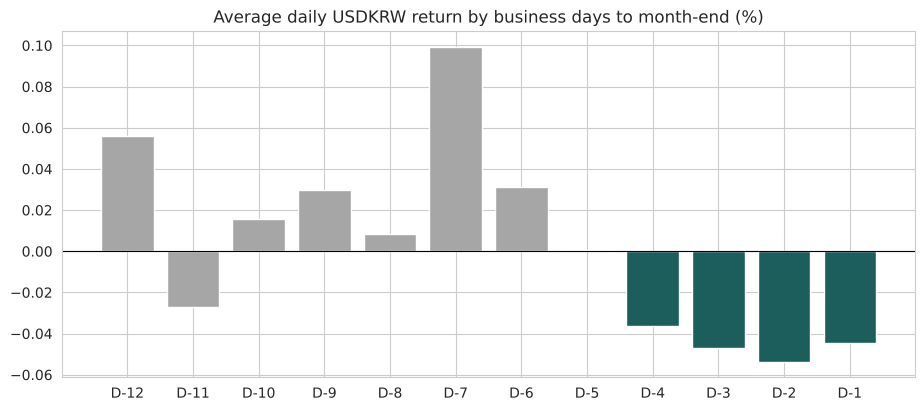

bd_to_end,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
평균 수익률(%),-0.0445,-0.0536,-0.0472,-0.0365,0.0004,0.031,0.0994,0.0082,0.0296,0.0155,-0.0273,0.0562
t값,-1.3800,-1.0600,-1.5800,-1.2000,0.0100,1.080,2.8800,0.2600,0.8500,0.4500,-0.7800,1.1700


In [ ]:
def describe(x):
    x = pd.Series(x).dropna()
    return pd.Series({
        "n": len(x),
        "승률(%)": (x > 0).mean() * 100,
        "평균(%)": x.mean() * 100,
        "중앙값(%)": x.median() * 100,
        "표준편차(%)": x.std() * 100,
        "t값": x.mean() / x.std() * np.sqrt(len(x)),
    })


by_day = df.groupby("bd_to_end")[["ret", "intra", "ov"]].mean().head(12) * 100
by_day_t = df.groupby("bd_to_end")["ret"].apply(lambda x: x.mean() / x.std() * np.sqrt(x.count())).head(12)

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [MAIN if k <= 5 else GRAY for k in by_day.index]
ax.bar([f"D-{int(k)}" for k in by_day.index], by_day["ret"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.invert_xaxis()
ax.set_title("Average daily USDKRW return by business days to month-end (%)")
plt.show()

pd.DataFrame({"평균 수익률(%)": by_day["ret"].round(4), "t값": by_day_t.round(2)}).T

D-4부터 월말까지 나흘이 음수다. 달력을 바로잡고 나니 D-5는 0에 가깝다. 구간은 처음 정한 5영업일을 그대로 쓰고, 길이를 바꾼 결과를 따로 본다.

일 단위 평균은 변동성이 몰려 나타나는 성질 때문에 t값이 부풀기 쉽다. 실제로는 한 달에 한 번 들어갔다 나오는 거래이므로 닷새 수익률을 합친 월 단위를 기본 단위로 삼는다. 손익은 달러 숏 기준이다.

In [ ]:
WINDOW = 5


def build_trades(data, mask, n_days):
    # 월별로 구간 수익률을 묶는다. 달러 숏 기준 손익이고, 조건 변수는 진입일(구간 직전 영업일) 값이다
    rows = []
    for ym, g in data[mask].groupby("ym"):
        if len(g) != n_days or g["ret"].isna().any():
            continue
        i = data.index.get_loc(g.index[0]) - 1
        if i < 0:
            continue
        e = data.iloc[i]
        rows.append({
            "ym": ym, "entry": data.index[i],
            "pnl": -g["ret"].sum(), "intra": -g["intra"].sum(), "ov": -g["ov"].sum(),
            "fut": -g["fret"].sum() if g["fret"].notna().all() else np.nan,
            "f_intra": -g["f_intra"].sum() if g["f_intra"].notna().all() else np.nan,
            "dev60": e["dev60"], "vol20": e["vol20"], "basis20": e["basis20"],
        })
    out = pd.DataFrame(rows).set_index("ym")
    out["year"] = out.index.year
    out["month"] = out.index.month
    return out


month_end = df["bd_to_end"] <= WINDOW
trades = build_trades(df, month_end, WINDOW)

base = pd.DataFrame({
    "일 단위 (현물)": describe(-df.loc[month_end, "ret"]),
    "거래 단위 (현물, 5일 합)": describe(trades["pnl"]),
    "거래 단위 (2008-10 제외)": describe(trades["pnl"].drop(pd.Period("2008-10"))),
    "거래 단위 (달러선물)": describe(trades["fut"]),
}).T
base.round(3)

,n,승률(%),평균(%),중앙값(%),표준편차(%),t값
일 단위 (현물),1562.0,52.497,0.036,0.031,0.640,2.241
"거래 단위 (현물, 5일 합)",311.0,58.199,0.184,0.188,1.191,2.727
거래 단위 (2008-10 제외),310.0,58.065,0.156,0.183,1.086,2.532
거래 단위 (달러선물),308.0,58.117,0.165,0.176,1.228,2.354


In [ ]:
# 구간 길이를 바꿔도 유지되는지
rows = {}
for w in [2, 3, 4, 5, 6, 7, 10]:
    t_w = build_trades(df, df["bd_to_end"] <= w, w)
    rows[f"월말 {w}영업일"] = describe(t_w["pnl"])
by_window = pd.DataFrame(rows).T
by_window.round(3)

,n,승률(%),평균(%),중앙값(%),표준편차(%),t값
월말 2영업일,312.0,55.449,0.099,0.061,0.947,1.843
월말 3영업일,311.0,55.305,0.146,0.117,1.157,2.223
월말 4영업일,311.0,56.913,0.184,0.064,1.203,2.699
월말 5영업일,311.0,58.199,0.184,0.188,1.191,2.727
월말 6영업일,311.0,58.521,0.153,0.221,1.296,2.081
월말 7영업일,311.0,56.270,0.055,0.177,1.366,0.710
월말 10영업일,311.0,54.019,-0.002,0.147,1.755,-0.025


311개월 기준으로 거래당 +0.18%, 승률 58%, t값 2.7이다. 2008년 10월을 빼도 2.5이고, 달러선물로 해도 비슷하다. 구간은 4~5일일 때 가장 뚜렷하고 7일을 넘기면 사라진다.

## 3. 가설 검증

판정 기준을 먼저 정해 둔다.

1. 두 집단의 평균 차이 또는 승률 차이가 5% 수준에서 유의하다.
2. 기간을 넷으로 나눠도 방향이 같다.
3. 월말이 아닌 구간에는 같은 조건이 통하지 않는다(조건 가설에만 해당).

모두 충족하면 채택, 방향만 맞으면 부분 지지, 방향조차 안 맞으면 기각이다.

### H1. 네고라면 서울 장중에만 나타난다

업체의 현물환 매도는 국내 은행을 거쳐 서울 시장 시간에 체결된다. 반면 야간의 환율 변화는 역외 NDF와 글로벌 달러가 만든다. 월말 하락이 네고 때문이라면 시가→종가 구간에 몰려 있고 종가→익일 시가 구간에는 없어야 한다. 글로벌 월말 리밸런싱 같은 요인이 원인이라면 야간에도 보일 것이다.

In [ ]:
h1 = pd.DataFrame({
    "장중 (시가→종가)": describe(trades["intra"]),
    "야간 (종가→익일 시가)": describe(trades["ov"]),
    "합계 (종가→종가)": describe(trades["pnl"]),
    "선물 장중": describe(trades["f_intra"]),
    "선물 합계": describe(trades["fut"]),
}).T
paired = stats.ttest_rel(trades["intra"], trades["ov"])
print(f"장중 - 야간 대응표본 t = {paired.statistic:.2f}, p = {paired.pvalue:.4f}")
h1.round(3)

장중 - 야간 대응표본 t = 2.62, p = 0.0091


,n,승률(%),평균(%),중앙값(%),표준편차(%),t값
장중 (시가→종가),311.0,61.093,0.191,0.235,0.883,3.821
야간 (종가→익일 시가),311.0,45.981,-0.007,-0.057,0.911,-0.138
합계 (종가→종가),311.0,58.199,0.184,0.188,1.191,2.727
선물 장중,308.0,57.143,0.098,0.148,0.919,1.880
선물 합계,308.0,58.117,0.165,0.176,1.228,2.354


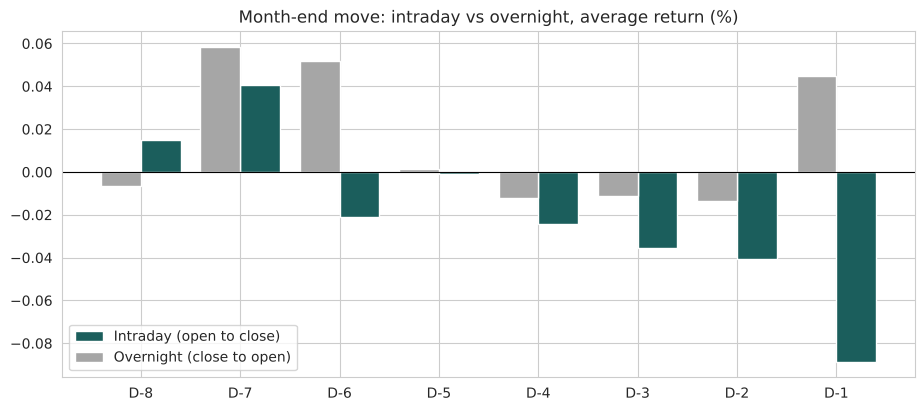

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
idx = np.arange(1, 9)
lab = [f"D-{k}" for k in idx]
ax.bar(np.arange(8) - 0.2, by_day.loc[idx, "intra"], width=0.4, color=MAIN, label="Intraday (open to close)")
ax.bar(np.arange(8) + 0.2, by_day.loc[idx, "ov"], width=0.4, color=GRAY, label="Overnight (close to open)")
ax.set_xticks(np.arange(8)); ax.set_xticklabels(lab)
ax.axhline(0, color="black", linewidth=0.8)
ax.invert_xaxis()
ax.set_title("Month-end move: intraday vs overnight, average return (%)")
ax.legend()
plt.show()

장중 +0.19%(t 3.8, 승률 61%), 야간 -0.01%. 둘의 차이도 유의하다(대응표본 t 2.6). 달러선물로 봐도 방향은 같지만 더 약하다(장중 +0.10%, t 1.9). 현물 기준으로 월말 하락은 전부 서울 장중에 생긴다. **채택.**

### H2. 네고가 몰리면 거래량이 늘어난다

실수요 물량이 더해지면 은행 간 거래량도 늘어야 한다. SMBS 거래량을 직전 60일 평균으로 나눈 값을 월말까지 남은 영업일별로 본다. 중개 거래량이 자리 잡은 2003년 이후만 쓴다.

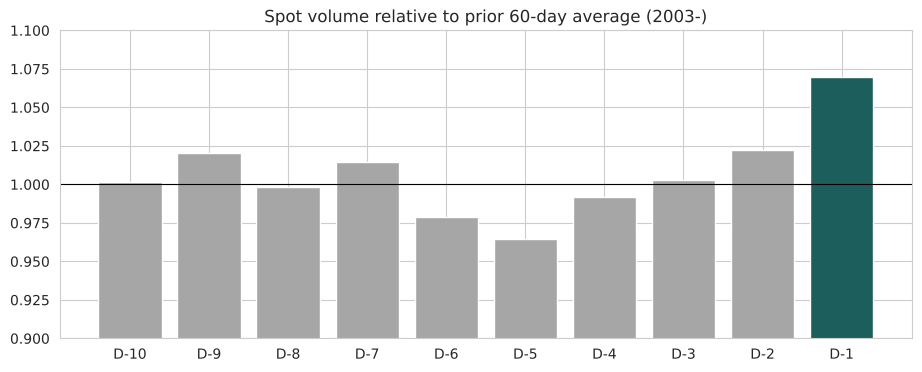

,상대 거래량,그 외 거래일,t값,p값
D-1,1.070,1.02,3.329,0.001
D-2,1.022,1.02,0.138,0.890
D-3,1.003,1.02,-1.050,0.295
D-4,0.992,1.02,-1.774,0.077
D-5,0.965,1.02,-3.608,0.000


In [ ]:
vol_sample = df[df.index >= "2003-01-01"]
vol_by_day = vol_sample.groupby("bd_to_end")["vol_rel"].mean().head(10)

other = vol_sample.loc[~(vol_sample["bd_to_end"] <= WINDOW), "vol_rel"].dropna()
rows = {}
for k in [1, 2, 3, 4, 5]:
    x = vol_sample.loc[vol_sample["bd_to_end"] == k, "vol_rel"].dropna()
    test = stats.ttest_ind(x, other, equal_var=False)
    rows[f"D-{k}"] = {"상대 거래량": x.mean(), "그 외 거래일": other.mean(), "t값": test.statistic, "p값": test.pvalue}
h2 = pd.DataFrame(rows).T

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar([f"D-{int(k)}" for k in vol_by_day.index], vol_by_day.values, color=[MAIN if k == 1 else GRAY for k in vol_by_day.index])
ax.axhline(1, color="black", linewidth=0.8)
ax.set_ylim(0.9, 1.1)
ax.invert_xaxis()
ax.set_title("Spot volume relative to prior 60-day average (2003-)")
plt.show()
h2.round(3)

월말 당일만 평소보다 7% 많고(t 3.3) 그 앞 나흘은 평소 수준이거나 오히려 적다. 장중 하락 폭도 월말 당일이 가장 크다. 물량이 닷새에 고르게 퍼지기보다 마지막 날에 몰린다는 뜻이다. **부분 지지.**

### H3. 환율이 내리는 국면에서 강하고, 오르는 국면에서 약하다

수출업체는 달러를 언제 팔지 고를 수 있다. 환율이 오르는 중이면 더 높은 값에 팔려고 매도를 미루고(래깅) 달러를 외화예금으로 들고 간다. 환율이 내리는 중이면 더 떨어지기 전에 팔려고 서두르고(리딩), 그동안 미뤄 둔 물량까지 월말에 겹친다.

반대 가설도 있다. 환율이 높을수록 좋은 값이라 매도가 늘어난다는 '고점 매도'다. 어느 쪽이 맞는지는 데이터가 정한다.

조건은 진입일 종가가 60일 이동평균보다 아래인지 위인지로 나눈다.

In [ ]:
def compare(tr, cond, y, names):
    # cond가 참/거짓인 두 집단의 평균 차이(Welch)와 승률 차이(비율 z검정)
    a, b = tr.loc[cond, y].dropna(), tr.loc[~cond, y].dropna()
    out = pd.DataFrame({names[0]: describe(a), names[1]: describe(b)}).T
    welch = stats.ttest_ind(a, b, equal_var=False)
    p1, p2, n1, n2 = (a > 0).mean(), (b > 0).mean(), len(a), len(b)
    p = (p1 * n1 + p2 * n2) / (n1 + n2)
    z = (p1 - p2) / np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    out.attrs["평균 차이 t"] = welch.statistic
    out.attrs["평균 차이 p"] = welch.pvalue
    out.attrs["승률 차이 z"] = z
    out.attrs["승률 차이 p"] = 2 * (1 - stats.norm.cdf(abs(z)))
    return out


def show(tab, title):
    print(title)
    print(tab.round(3).to_string())
    print("  평균 차이: t = {:.2f} (p = {:.3f}) / 승률 차이: z = {:.2f} (p = {:.3f})\n".format(
        tab.attrs["평균 차이 t"], tab.attrs["평균 차이 p"], tab.attrs["승률 차이 z"], tab.attrs["승률 차이 p"]))


down = trades["dev60"] < 0
h3_pnl = compare(trades, down, "pnl", ["환율 < 60일 평균", "환율 ≥ 60일 평균"])
h3_intra = compare(trades, down, "intra", ["환율 < 60일 평균", "환율 ≥ 60일 평균"])
show(h3_pnl, "종가→종가")
show(h3_intra, "장중")

종가→종가
                 n   승률(%)  평균(%)  중앙값(%)  표준편차(%)     t값
환율 < 60일 평균  147.0  61.224  0.263   0.255    1.018  3.128
환율 ≥ 60일 평균  164.0  55.488  0.114   0.112    1.327  1.099
  평균 차이: t = 1.12 (p = 0.265) / 승률 차이: z = 1.02 (p = 0.306)

장중
                 n   승률(%)  평균(%)  중앙값(%)  표준편차(%)     t값
환율 < 60일 평균  147.0  67.347  0.286   0.324    0.807  4.293
환율 ≥ 60일 평균  164.0  55.488  0.107   0.086    0.941  1.453
  평균 차이: t = 1.81 (p = 0.072) / 승률 차이: z = 2.14 (p = 0.032)



방향은 래깅·리딩 쪽이다. 고점 매도 가설은 맞지 않는다.

다만 이것이 월말과 무관한 단순 추세 추종일 수 있다. 환율이 내리는 중이면 어느 닷새를 잡아도 숏이 벌 수 있기 때문이다. 같은 조건을 월중과 월초 구간에 적용해서 확인한다.

In [ ]:
# 플라시보: 같은 조건을 월말이 아닌 구간에 적용한다
mid = build_trades(df, (df["bd_to_end"] >= 9) & (df["bd_to_end"] <= 13), 5)
start = build_trades(df, df["bd_from_start"] <= 5, 5)

placebo = pd.concat({
    "월말 (D-5~D-1)": compare(trades, trades["dev60"] < 0, "pnl", ["평균 아래", "평균 위"]),
    "월중 (D-13~D-9)": compare(mid, mid["dev60"] < 0, "pnl", ["평균 아래", "평균 위"]),
    "월초 (1~5영업일)": compare(start, start["dev60"] < 0, "pnl", ["평균 아래", "평균 위"]),
})
placebo.round(3)

n   승률(%)  평균(%)  중앙값(%)  표준편차(%)     t값
월말 (D-5~D-1)  평균 아래  147.0  61.224  0.263   0.255    1.018  3.128
              평균 위   164.0  55.488  0.114   0.112    1.327  1.099
월중 (D-13~D-9) 평균 아래  152.0  48.684 -0.043  -0.011    1.142 -0.461
              평균 위   160.0  51.875 -0.135   0.037    1.878 -0.910
월초 (1~5영업일)   평균 아래  161.0  51.553 -0.040   0.032    1.297 -0.389
              평균 위   150.0  52.667 -0.139   0.085    1.773 -0.964

In [ ]:
# 이동평균 길이를 바꿔도, 구간을 나눠도 같은 방향인지
c = df["close"].ffill()
rows = {}
for n in [20, 40, 60, 120, 250]:
    dev = (c / c.rolling(n).mean() - 1).reindex(trades["entry"]).values
    for name, m in [("아래", dev < 0), ("위", dev >= 0)]:
        rows[(f"{n}일", name)] = describe(trades.loc[m, "intra"])
by_ma = pd.DataFrame(rows).T

period = pd.cut(trades["year"], [1998, 2007, 2015, 2021, 2100], labels=["1999-2007", "2008-2015", "2016-2021", "2022-"])
trend = np.where(trades["dev60"] < 0, "평균 아래", "평균 위")
by_period = trades.groupby([period, trend], observed=True)[["pnl", "intra"]].agg(["count", "mean", lambda x: (x > 0).mean()])
by_period.columns = ["n", "종가 평균", "종가 승률", "n2", "장중 평균", "장중 승률"]
by_period = by_period.drop(columns="n2")
by_period[["종가 평균", "장중 평균"]] *= 100
by_period[["종가 승률", "장중 승률"]] *= 100
up_share = (trades["dev60"] >= 0).groupby(period, observed=True).mean() * 100

print(by_ma.round(3).to_string(), "\n")
print(by_period.round(2).to_string(), "\n")
print("환율이 60일 평균 위에서 월말을 맞은 비율(%)")
print(up_share.round(1).to_string())

             n   승률(%)  평균(%)  중앙값(%)  표준편차(%)     t값
20일  아래  141.0  67.376  0.274   0.324    0.751  4.337
     위   169.0  56.213  0.130   0.151    0.974  1.735
40일  아래  150.0  67.333  0.292   0.308    0.775  4.611
     위   159.0  55.346  0.104   0.083    0.967  1.357
60일  아래  147.0  67.347  0.286   0.324    0.807  4.293
     위   161.0  55.901  0.114   0.089    0.944  1.536
120일 아래  153.0  67.320  0.285   0.334    0.766  4.606
     위   152.0  54.605  0.098   0.070    0.986  1.222
250일 아래  159.0  66.667  0.275   0.324    0.751  4.626
     위   140.0  54.286  0.076   0.070    0.997  0.900 

                  n  종가 평균  종가 승률  장중 평균  장중 승률
year                                           
1999-2007 평균 아래  49   0.21  59.18   0.32  71.43
          평균 위   42   0.07  54.76   0.21  59.52
2008-2015 평균 아래  49   0.30  57.14   0.30  73.47
          평균 위   47   0.29  63.83   0.09  55.32
2016-2021 평균 아래  33   0.27  69.70   0.19  57.58
          평균 위   39   0.15  53.85   0.12  51.28
2022-     평균 아래  16 

월중과 월초에는 평균 아래든 위든 숏이 벌지 못한다. 추세 조건은 월말에만 통하므로 단순한 추세 추종이 아니다.

- 장중 승률 67% 대 55% (p 0.03), 장중 평균 +0.29% 대 +0.11% (p 0.07). 종가→종가 평균 차이는 유의하지 않다(p 0.27).
- 이동평균을 20일에서 250일까지 바꿔도 결과가 거의 같다.
- 네 구간 모두 평균 아래일 때 장중 평균이 더 높다.

2022년 이후 효과가 약해진 이유도 여기서 설명된다. 이 기간 52개월 가운데 36개월(69%)을 환율이 60일 평균 위에서 맞았고 그때의 종가→종가 손익은 -0.10%였다. 평균 아래였던 16개월은 +0.30%로 예전과 같다. 효과가 없어졌다기보다 효과가 약한 국면이 길었다.

승률 차이는 유의하고 평균 차이는 10% 수준에 걸친다. **부분 지지.**

### H4. 달러 금리가 원화 금리보다 높으면 약하다

달러 예금 금리가 높으면 달러를 들고 있는 기회비용이 작아서 매도를 미루기 쉽다. 달러선물 베이시스(선물-현물)의 부호가 곧 원화 금리와 달러 금리의 차이이므로 진입일 직전 20일 평균 베이시스가 양수인지 음수인지로 나눈다.

### H5. 분기말에 더 강하다

분기 결산과 부채비율 관리 때문에 분기말에는 외화를 원화로 바꾸려는 수요가 더 많을 것이다.

### H6. 변동성이 낮을 때 더 강하다

시장이 조용하면 뉴스보다 수급이 가격을 정한다. 진입일의 20일 변동성이 중앙값보다 낮은 달과 높은 달을 비교한다.

In [ ]:
pos_basis = trades["basis20"] > 0
h4 = compare(trades, pos_basis, "intra", ["베이시스 > 0 (원화금리 우위)", "베이시스 ≤ 0 (달러금리 우위)"])
show(h4, "H4 금리차 - 장중")
show(compare(trades, pos_basis, "fut", ["베이시스 > 0", "베이시스 ≤ 0"]), "H4 금리차 - 선물 종가→종가 (캐리 포함)")

quarter_end = trades["month"].isin([3, 6, 9, 12])
h5 = compare(trades, quarter_end, "pnl", ["분기말 월", "그 외 월"])
show(h5, "H5 분기말 - 종가→종가")
show(compare(trades, quarter_end, "intra", ["분기말 월", "그 외 월"]), "H5 분기말 - 장중")

low_vol = trades["vol20"] <= trades["vol20"].median()
h6 = compare(trades, low_vol, "pnl", ["저변동성", "고변동성"])
show(h6, "H6 변동성 - 종가→종가")
show(compare(trades, low_vol, "intra", ["저변동성", "고변동성"]), "H6 변동성 - 장중")

H4 금리차 - 장중
                        n   승률(%)  평균(%)  중앙값(%)  표준편차(%)     t값
베이시스 > 0 (원화금리 우위)  170.0  66.471  0.217   0.336    0.783  3.617
베이시스 ≤ 0 (달러금리 우위)  141.0  54.610  0.160   0.058    0.993  1.917
  평균 차이: t = 0.55 (p = 0.581) / 승률 차이: z = 2.14 (p = 0.033)

H4 금리차 - 선물 종가→종가 (캐리 포함)
              n   승률(%)  평균(%)  중앙값(%)  표준편차(%)     t값
베이시스 > 0  169.0  62.130  0.209   0.248    1.016  2.679
베이시스 ≤ 0  139.0  53.237  0.110   0.116    1.446  0.899
  평균 차이: t = 0.68 (p = 0.496) / 승률 차이: z = 1.57 (p = 0.115)

H5 분기말 - 종가→종가
           n   승률(%)  평균(%)  중앙값(%)  표준편차(%)     t값
분기말 월  104.0  56.731  0.189   0.258    1.248  1.547
그 외 월  207.0  58.937  0.182   0.149    1.165  2.243
  평균 차이: t = 0.05 (p = 0.957) / 승률 차이: z = -0.37 (p = 0.710)

H5 분기말 - 장중
           n   승률(%)  평균(%)  중앙값(%)  표준편차(%)     t값
분기말 월  104.0  65.385  0.145   0.332    0.955  1.550
그 외 월  207.0  58.937  0.215   0.168    0.846  3.648
  평균 차이: t = -0.63 (p = 0.531) / 승률 차이: z = 1.10 (p = 0.271)

H6 변동성 - 종가→종가
  

In [ ]:
by_month = trades.groupby("month")[["pnl", "intra"]].agg(["mean", lambda x: (x > 0).mean()]) * 100
by_month.columns = ["종가 평균(%)", "종가 승률(%)", "장중 평균(%)", "장중 승률(%)"]
by_month.round(2).T

month,1,2,3,4,5,6,7,8,9,10,11,12
종가 평균(%),0.07,-0.30,0.27,0.21,0.15,0.18,0.17,0.11,-0.25,0.75,0.31,0.56
종가 승률(%),57.69,40.74,55.56,57.69,52.00,64.00,52.00,69.23,34.62,65.38,76.92,73.08
장중 평균(%),0.13,0.00,0.33,0.09,0.17,0.13,0.38,0.08,-0.18,0.62,0.26,0.30
장중 승률(%),57.69,55.56,77.78,53.85,60.00,60.00,64.00,46.15,57.69,73.08,61.54,65.38


- H4: 원화 금리가 높은 국면의 장중 승률이 66%로 반대 국면(55%)보다 높다(p 0.03). 평균 차이는 유의하지 않다. **부분 지지.**
- H5: 분기말 월과 나머지 월의 차이가 없다. **기각.**
- H6: 평균과 승률 모두 유의한 차이가 없다. **기각.**

월별로 보면 2월과 9월만 종가→종가 손익이 음수다. 설과 추석 전에 원화가 필요해서 네고가 월말보다 앞당겨졌을 수 있지만, 표를 보고 나서 떠올린 설명이고 표본도 달마다 26개뿐이라 가설로 세우지 않았다.

## 4. 전략

검증 결과를 규칙으로 옮긴다.

- A. 기본: D-6 종가에 달러 매도, 월말 종가에 청산 (처음 코드의 전략)
- B. A를 달러선물로 실행. 선물 가격에는 스왑포인트가 들어 있어서 숏을 넘기는 비용이 반영된다.
- C. A에 추세 필터. 진입일 종가가 60일 이동평균 아래일 때만 거래 (H3)
- D. 장중만. 월말 5영업일 동안 매일 시가에 팔고 종가에 되산다 (H1)
- E. D에 추세 필터

비용은 편도 1bp를 기본으로 둔다. 달러선물 호가 단위 0.1원이 0.7bp 정도다. 성과는 원금 이자를 뺀 FX 손익으로만 계산한다.

In [ ]:
def backtest(data, window=5, mode="close", instrument="spot", ma=None, entry_filter=None,
             slippage_bps=1.0, stop_loss=None, take_profit=None, std_window=20):
    """월말 달러 숏.
    mode       'close'    : D-(window+1) 종가 매도, 월말 종가 청산
               'intraday' : 구간 동안 매일 시가 매도, 종가 청산
    instrument 'spot' 또는 'futures' (선물은 스왑포인트가 가격에 들어 있다)
    ma         숫자를 주면 진입일 종가가 ma일 이동평균 아래일 때만 거래
    entry_filter 날짜별 참/거짓. 진입일 값이 참인 달만 거래
    stop_loss / take_profit : 거래 누적 손익이 std_window일 변동성의 k배를 넘은 날 종가에 청산 (close 모드)
    """
    col = {("close", "spot"): "ret", ("close", "futures"): "fret",
           ("intraday", "spot"): "intra", ("intraday", "futures"): "f_intra"}[(mode, instrument)]
    r = data[col]
    in_window = data["bd_to_end"] <= window
    px = data["close"].ffill()
    below_ma = (px < px.rolling(ma).mean()) if ma else pd.Series(True, index=data.index)
    if entry_filter is not None:
        below_ma = below_ma & entry_filter.reindex(data.index).fillna(False).astype(bool)
    band = r.rolling(std_window).std()

    pos = pd.Series(0.0, index=data.index)
    loc = {d: i for i, d in enumerate(data.index)}
    for ym, g in data[in_window].groupby("ym"):
        if len(g) != window or r.loc[g.index].isna().any():
            continue
        i = loc[g.index[0]] - 1
        if i < 0 or not below_ma.iloc[i]:
            continue
        pos.loc[g.index] = -1.0
        if mode == "close" and (stop_loss is not None or take_profit is not None):
            cum = 0.0
            for n, day in enumerate(g.index):
                cum += -r.loc[day]
                b = band.loc[day]
                if pd.isna(b) or b == 0:
                    continue
                if (take_profit is not None and cum >= take_profit * b) or \
                   (stop_loss is not None and cum <= -stop_loss * b):
                    pos.loc[g.index[n + 1:]] = 0.0
                    break

    out = pd.DataFrame({"pos": pos, "gross": (pos * r).fillna(0.0), "ym": data["ym"]})
    if mode == "close":
        turnover = (pos - pos.shift(1).fillna(0.0)).abs()       # 진입 1회 + 청산 1회
    else:
        turnover = 2 * pos.abs()                                # 매일 시가 진입, 종가 청산
    out["cost"] = turnover * slippage_bps / 1e4
    out["pnl"] = out["gross"] - out["cost"]

    # 거래(월) 단위 손익
    w = out[in_window]
    n_held = w.groupby("ym")["pos"].apply(lambda p: (p != 0).sum())
    traded = n_held > 0
    sides = 2 if mode == "close" else 2 * n_held[traded]
    trade_pnl = w.groupby("ym")["gross"].sum()[traded] - sides * slippage_bps / 1e4
    return out, trade_pnl


def performance(daily, trade_pnl, start=None, end=None):
    x = daily["pnl"]
    tp = trade_pnl
    if start is not None:
        x = x[x.index >= start]; tp = tp[tp.index >= pd.Period(start, "M")]
    if end is not None:
        x = x[x.index < end]; tp = tp[tp.index < pd.Period(end, "M")]
    years = (x.index[-1] - x.index[0]).days / 365.25
    per_year = len(x) / years
    eq = (1 + x).cumprod()
    return pd.Series({
        "거래 횟수": len(tp),
        "승률(%)": (tp > 0).mean() * 100,
        "거래당 평균(%)": tp.mean() * 100,
        "t값": tp.mean() / tp.std() * np.sqrt(len(tp)),
        "총수익률(%)": (eq.iloc[-1] - 1) * 100,
        "연환산 수익률(%)": (eq.iloc[-1] ** (1 / years) - 1) * 100,
        "연환산 변동성(%)": x.std() * np.sqrt(per_year) * 100,
        "Sharpe": x.mean() / x.std() * np.sqrt(per_year),
        "MDD(%)": (eq / eq.cummax() - 1).min() * 100,
    })

In [ ]:
STRATEGIES = {
    "A. 기본 (현물, 종가→종가)": dict(mode="close", instrument="spot"),
    "B. A를 달러선물로": dict(mode="close", instrument="futures"),
    "C. A + 추세 필터": dict(mode="close", instrument="spot", ma=60),
    "D. 장중만 (시가 매도, 종가 청산)": dict(mode="intraday", instrument="spot"),
    "E. D + 추세 필터": dict(mode="intraday", instrument="spot", ma=60),
}

runs = {name: backtest(df, slippage_bps=1.0, **kw) for name, kw in STRATEGIES.items()}
result = pd.DataFrame({name: performance(*run) for name, run in runs.items()}).T
result.round(2)

,거래 횟수,승률(%),거래당 평균(%),t값,총수익률(%),연환산 수익률(%),연환산 변동성(%),Sharpe,MDD(%)
"A. 기본 (현물, 종가→종가)",311.0,56.91,0.16,2.43,61.48,1.77,4.84,0.39,-12.07
B. A를 달러선물로,324.0,58.02,0.15,2.17,56.14,1.65,4.50,0.39,-13.27
C. A + 추세 필터,147.0,59.18,0.24,2.89,41.34,1.28,2.81,0.47,-4.60
"D. 장중만 (시가 매도, 종가 청산)",311.0,55.95,0.09,1.82,30.44,0.98,3.68,0.28,-12.15
E. D + 추세 필터,147.0,63.27,0.19,2.79,30.41,0.98,2.35,0.43,-5.73


In [ ]:
# 비용 가정에 따른 Sharpe (편도 bp)
cost_grid = pd.DataFrame({
    name: {f"{bps}bp": performance(*backtest(df, slippage_bps=bps, **kw))["Sharpe"] for bps in [0, 1, 2, 5]}
    for name, kw in STRATEGIES.items()
}).T
cost_grid.round(2)

,0bp,1bp,2bp,5bp
"A. 기본 (현물, 종가→종가)",0.43,0.39,0.34,0.20
B. A를 달러선물로,0.44,0.39,0.33,0.17
C. A + 추세 필터,0.50,0.47,0.43,0.31
"D. 장중만 (시가 매도, 종가 청산)",0.59,0.28,-0.03,-0.95
E. D + 추세 필터,0.65,0.43,0.20,-0.49


In [ ]:
# 손절·익절(20일 변동성의 2배)을 붙이면
stop_run = backtest(df, mode="close", instrument="spot", slippage_bps=1.0, stop_loss=2.0, take_profit=2.0)
pd.DataFrame({
    "A. 기본": performance(*runs["A. 기본 (현물, 종가→종가)"]),
    "A + 손절·익절 2σ": performance(*stop_run),
}).T.round(2)

,거래 횟수,승률(%),거래당 평균(%),t값,총수익률(%),연환산 수익률(%),연환산 변동성(%),Sharpe,MDD(%)
A. 기본,311.0,56.91,0.16,2.43,61.48,1.77,4.84,0.39,-12.07
A + 손절·익절 2σ,311.0,56.91,0.14,1.86,48.86,1.47,4.45,0.35,-11.25


- 기본형 A는 Sharpe 0.39, MDD -12%다. 선물로 실행한 B도 거의 같아서 스왑포인트가 결과를 바꾸지는 않는다.
- 추세 필터를 붙인 C는 거래가 절반으로 줄지만 Sharpe 0.47, MDD -4.6%로 좋아진다.
- 장중 전략 D는 비용이 없으면 가장 좋지만(Sharpe 0.59) 닷새 동안 열 번 체결해야 해서 편도 2bp만 돼도 남는 게 없다.
- 20일 변동성의 2배에 손절·익절을 걸면 오히려 나빠진다. 수급 효과는 닷새에 걸쳐 조금씩 쌓이는데 중간에 끊어 버리기 때문이다.

### 앞 절반에서 만든 규칙이 뒤 절반에서도 통하는가

In [ ]:
SPLIT = "2013-01-01"
oos = pd.concat({
    "1999-2012": pd.DataFrame({n: performance(*run, end=SPLIT) for n, run in runs.items()}).T,
    "2013-2026": pd.DataFrame({n: performance(*run, start=SPLIT) for n, run in runs.items()}).T,
})
oos[["거래 횟수", "승률(%)", "거래당 평균(%)", "t값", "Sharpe", "MDD(%)"]].round(2)

거래 횟수  승률(%)  거래당 평균(%)    t값  Sharpe  MDD(%)
1999-2012 A. 기본 (현물, 종가→종가)      151.0  57.62       0.25  2.29    0.50  -12.07
          B. A를 달러선물로            164.0  60.37       0.24  2.25    0.57  -13.27
          C. A + 추세 필터            82.0  54.88       0.31  2.68    0.59   -4.60
          D. 장중만 (시가 매도, 종가 청산)  151.0  59.60       0.16  1.94    0.40  -12.15
          E. D + 추세 필터            82.0  67.07       0.24  2.60    0.53   -5.73
2013-2026 A. 기본 (현물, 종가→종가)      160.0  56.25       0.08  1.00    0.24   -9.47
          B. A를 달러선물로            160.0  55.62       0.05  0.60    0.15  -12.08
          C. A + 추세 필터            65.0  64.62       0.16  1.30    0.31   -4.00
          D. 장중만 (시가 매도, 종가 청산)  160.0  52.50       0.03  0.47    0.12   -7.98
          E. D + 추세 필터            65.0  58.46       0.11  1.21    0.29   -3.52

In [ ]:
# 장중 효과 자체(비용 전)는 뒤 절반에도 남아 있는지
half = np.where(trades["year"] < 2013, "1999-2012", "2013-2026")
pd.DataFrame({k: describe(trades.loc[half == k, "intra"]) for k in ["1999-2012", "2013-2026"]}).T.round(3)

,n,승률(%),평균(%),중앙값(%),표준편차(%),t값
1999-2012,151.0,64.901,0.259,0.335,1.004,3.164
2013-2026,160.0,57.500,0.128,0.171,0.749,2.160


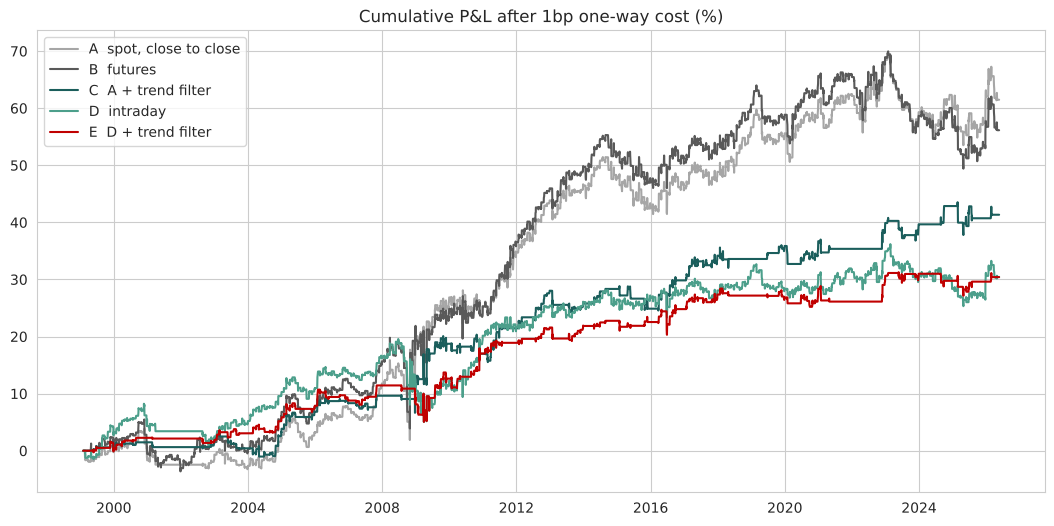

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
labels = ["A  spot, close to close", "B  futures", "C  A + trend filter", "D  intraday", "E  D + trend filter"]
palette = [GRAY, "#595959", MAIN, SUB, RED]
for (name, (daily, _)), label, color in zip(runs.items(), labels, palette):
    ax.plot(daily.index, ((1 + daily["pnl"]).cumprod() - 1) * 100, label=label, color=color, linewidth=1.5)
ax.set_title("Cumulative P&L after 1bp one-way cost (%)")
ax.legend()
plt.show()

In [ ]:
# 기준금리 이자를 더하면 (원금을 현금으로 들고 있다고 볼 때). 전략 성과가 아니라 참고용이다
daily_a = runs["A. 기본 (현물, 종가→종가)"][0]
rate = pd.merge_asof(pd.DataFrame({"date": daily_a.index}), rate_table, on="date").set_index("date")["rate"].fillna(0) / 100
gap_days = pd.Series(daily_a.index, index=daily_a.index).diff().dt.days.fillna(0)
cash = rate * gap_days / 365
print(f"FX 손익만: {((1 + daily_a['pnl']).prod() - 1) * 100:.1f}%  /  기준금리 이자 포함: {((1 + daily_a['pnl'] + cash).prod() - 1) * 100:.1f}%")

FX 손익만: 61.5%  /  기준금리 이자 포함: 257.7%


2013년 이후로는 모든 전략이 약해졌다. 기본형의 거래당 손익은 0.26%에서 0.08%로 줄었고 t값은 1.0이다. 추세 필터를 붙여도 0.16%(t 1.3)다. 순서는 유지되지만(C > A, E > D) 뒤 절반만으로는 유의하다고 말할 수 없다.

장중 효과 자체는 2013년 이후에도 비용 전 기준으로 유의하다. 사라진 것은 효과가 아니라 비용을 내고 남는 몫이다.

참고로 원금에 기준금리 이자를 더하면 누적 수익률이 훨씬 커 보이지만 그건 전략이 번 돈이 아니다.

## 5. 외부 변수

지금까지는 환율 자료만 썼다. 여기서는 DXY, USD/JPY, 미국과 한국 금리, KOSPI, S&P500, VIX, WTI를 붙여 두 가지를 본다.

- 월말 하락이 글로벌 달러나 주식 움직임으로 설명되는가
- 어떤 시장 국면에서 효과가 강한가

외부 자료가 모두 갖춰지고 현물 종가가 다시 이어지는 2002년 8월부터 쓴다. 시차 처리가 중요하다. 서울 종가 시점에는 전날 뉴욕 종가까지만 알 수 있으므로 미국·글로벌 자산과 국내 금리는 전일 값까지, KOSPI는 당일 값까지 쓴다.

In [ ]:
mkt = pd.read_excel("/content/drive/MyDrive/Quant/market_data.xlsx", index_col=0, parse_dates=True)
mkt.loc[mkt["WTI_close"] <= 0, "WTI_close"] = np.nan        # 2020-04 마이너스 유가
pd.DataFrame({"시작": mkt.apply(lambda c: c.first_valid_index().date()), "행 수": mkt.count()}).loc[
    ["DXY_close", "USDJPY_close", "US10Y_close", "US2Y_close", "KR3Y_close", "KR10Y_close", "KOSPI_close", "SPX_close", "VIX_close", "WTI_close"]]

,시작,행 수
DXY_close,1998-01-01,7277
USDJPY_close,1998-01-01,7468
US10Y_close,1998-01-02,7222
US2Y_close,1998-01-02,7192
KR3Y_close,1998-11-13,6906
KR10Y_close,2000-12-18,6386
KOSPI_close,1998-01-05,7082
SPX_close,1998-01-02,7232
VIX_close,1998-01-02,7234
WTI_close,2000-08-23,6555


In [ ]:
def known_at_close(series, same_day=False):
    # 서울 종가 시점에 알 수 있는 마지막 값. same_day=False면 전일 값까지만 쓴다
    s_ = series.dropna()
    pos = np.searchsorted(s_.index.values, df.index.values, side="right" if same_day else "left") - 1
    return pd.Series(np.where(pos >= 0, s_.values[np.clip(pos, 0, None)], np.nan), index=df.index)


EXT_START = "2002-08-01"      # 현물 종가가 다시 이어지고 외부 자료가 모두 있는 첫 달

lv = pd.DataFrame({
    "DXY": known_at_close(mkt["DXY_close"]),
    "USDJPY": known_at_close(mkt["USDJPY_close"]),
    "SPX": known_at_close(mkt["SPX_close"]),
    "VIX": known_at_close(mkt["VIX_close"]),
    "WTI": known_at_close(mkt["WTI_close"]),
    "US10Y": known_at_close(mkt["US10Y_close"]),
    "US2Y": known_at_close(mkt["US2Y_close"]),
    "KR10Y": known_at_close(mkt["KR10Y_close"]),
    "KR3Y": known_at_close(mkt["KR3Y_close"]),
    "KOSPI": known_at_close(mkt["KOSPI_close"], same_day=True),   # 서울 장과 같이 끝난다
})

sig = pd.DataFrame(index=df.index)
sig["KRW_down"] = df["dev60"] < 0
for a in ["DXY", "USDJPY", "SPX", "KOSPI", "WTI"]:
    sig[f"{a}_dev60"] = lv[a] / lv[a].rolling(60).mean() - 1
for a in ["US10Y", "US2Y"]:
    sig[f"{a}_chg60"] = lv[a] - lv[a].rolling(60).mean()
sig["VIX"] = lv["VIX"]
sig["spread10"] = lv["KR10Y"] - lv["US10Y"]
sig["spread_short"] = lv["KR3Y"] - lv["US2Y"]

ext = trades[trades.index >= pd.Period(EXT_START, "M")].copy()
ext = ext.join(sig.reindex(ext["entry"]).set_index(ext.index))
print(f"{len(ext)}개월 ({ext.index.min()} ~ {ext.index.max()})")
pd.DataFrame({"종가→종가": describe(ext["pnl"]), "장중": describe(ext["intra"]), "야간": describe(ext["ov"])}).T.round(3)

285개월 (2002-08 ~ 2026-04)


,n,승률(%),평균(%),중앙값(%),표준편차(%),t값
종가→종가,285.0,58.246,0.208,0.178,1.204,2.910
장중,285.0,61.053,0.188,0.233,0.886,3.576
야간,285.0,47.719,0.020,-0.014,0.932,0.365


### G0. 글로벌 요인으로 설명되지 않는다

월말에는 주식이 오르는 경향이 있다고 알려져 있다. 주식이 오르고 달러가 약해지는 날 원화가 강한 것은 당연하므로, 월말 환율 하락이 사실은 그 반영일 수 있다. 같은 닷새 동안 다른 자산이 어떻게 움직였는지 보고, 그 움직임을 통제한 뒤에도 월말 더미가 남는지 확인한다.

In [ ]:
sub = df[df.index >= EXT_START].copy()
in_me = sub["bd_to_end"] <= WINDOW

# 같은 닷새 동안 다른 자산은 어떻게 움직였나 (달러 숏과 견주려고 부호를 뒤집지 않은 원래 수익률)
rows = {"USD/KRW": describe(-ext["pnl"])}
for a in ["DXY", "USDJPY", "KOSPI", "SPX"]:
    r_a = mkt[f"{a}_close"].dropna().pct_change().reindex(sub.index)
    rows[a] = describe(r_a[in_me].groupby(sub.loc[in_me, "ym"]).sum().reindex(ext.index))
other_assets = pd.DataFrame(rows).T
other_assets.round(3)

,n,승률(%),평균(%),중앙값(%),표준편차(%),t값
USD/KRW,285.0,41.754,-0.208,-0.178,1.204,-2.910
DXY,285.0,44.211,-0.102,-0.090,0.995,-1.733
USDJPY,285.0,49.123,-0.038,-0.011,1.214,-0.528
KOSPI,285.0,52.281,0.298,0.165,2.967,1.694
SPX,285.0,59.298,0.270,0.243,2.185,2.087


In [ ]:
# 글로벌 변수를 통제해도 월말 더미가 남는가
sub["me"] = in_me.astype(int)
sub["kospi_intra"] = (mkt["KOSPI_close"] / mkt["KOSPI_open"] - 1).reindex(sub.index) * 100
sub["kospi_ret"] = mkt["KOSPI_close"].dropna().pct_change().reindex(sub.index) * 100
sub["dxy_same"] = mkt["DXY_close"].dropna().pct_change().reindex(sub.index) * 100
sub["jpy_same"] = mkt["USDJPY_close"].dropna().pct_change().reindex(sub.index) * 100
sub["spx_prev"] = known_at_close(mkt["SPX_close"].dropna().pct_change()).reindex(sub.index) * 100
sub["dxy_prev"] = known_at_close(mkt["DXY_close"].dropna().pct_change()).reindex(sub.index) * 100


def me_coef(y, controls):
    z = sub.dropna(subset=[y] + controls)
    fit = sm.OLS(z[y] * 100, sm.add_constant(z[["me"] + controls])).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    return {"월말 더미 계수(%)": fit.params["me"], "t값": fit.tvalues["me"], "R2": fit.rsquared, "n": len(z)}


controls = pd.DataFrame({
    "장중: 통제 없음": me_coef("intra", []),
    "장중: KOSPI 장중 + 전일 S&P500, DXY": me_coef("intra", ["kospi_intra", "spx_prev", "dxy_prev"]),
    "종가→종가: 통제 없음": me_coef("ret", []),
    "종가→종가: KOSPI, S&P500, DXY, USD/JPY": me_coef("ret", ["kospi_ret", "spx_prev", "dxy_prev", "dxy_same", "jpy_same"]),
    "야간: 전일 S&P500, DXY": me_coef("ov", ["spx_prev", "dxy_prev"]),
}).T
controls.round(3)

,월말 더미 계수(%),t값,R2,n
장중: 통제 없음,-0.048,-3.699,0.002,5879.0
"장중: KOSPI 장중 + 전일 S&P500, DXY",-0.045,-3.646,0.124,5870.0
종가→종가: 통제 없음,-0.063,-3.502,0.002,5878.0
"종가→종가: KOSPI, S&P500, DXY, USD/JPY",-0.051,-3.456,0.313,5676.0
"야간: 전일 S&P500, DXY",-0.003,-0.265,0.359,5878.0


같은 닷새 동안 KOSPI와 S&P500은 평균 0.3% 오르고 DXY는 0.1% 내린다. 의심할 만한 상황이다. 하지만 KOSPI 장중 수익률과 전일 S&P500, DXY를 통제해도 장중 월말 더미는 -0.048%에서 -0.045%로 거의 그대로다(t -3.6). 종가 기준으로 당일 DXY와 USD/JPY까지 넣어도 -0.051%(t -3.5)가 남는다. 야간 구간은 글로벌 변수가 설명하고 월말 더미는 0이다. **채택.** 월말 하락은 글로벌 요인과 별개인 원화 고유의 현상이다.

### G1. 글로벌 달러가 약한 국면에서 강하다

H3에서는 원화 자체의 추세만 봤다. 업체가 매도 시점을 정할 때 보는 것은 달러 전반의 방향일 것이다. DXY와 USD/JPY가 60일 평균 아래에 있으면 달러 약세 기대가 넓게 깔려 있다는 뜻이고, 그때 매도를 서두를 유인이 크다. 엔은 원화와 같이 움직이는 경향이 강해서 원화의 선행 신호로도 읽힌다.

In [ ]:
def test_conditions(tr, conds):
    # conds: {이름: 참/거짓 Series}. 참인 달과 거짓인 달의 종가→종가, 장중 손익을 나란히
    rows = []
    for name, cond in conds.items():
        ok = cond.notna()
        for y, label in [("pnl", "종가"), ("intra", "장중")]:
            tab = compare(tr[ok], cond[ok].astype(bool), y, ["참", "거짓"])
            rows.append({"조건": name, "손익": label,
                         "참 n": int(tab.iloc[0]["n"]), "참 승률": tab.iloc[0]["승률(%)"], "참 평균": tab.iloc[0]["평균(%)"],
                         "거짓 n": int(tab.iloc[1]["n"]), "거짓 승률": tab.iloc[1]["승률(%)"], "거짓 평균": tab.iloc[1]["평균(%)"],
                         "평균 차이 p": tab.attrs["평균 차이 p"], "승률 차이 p": tab.attrs["승률 차이 p"]})
    return pd.DataFrame(rows).set_index(["조건", "손익"])


def below(col):          # 60일 평균 아래. 값이 없으면 NaN으로 남긴다
    return (ext[col] < 0).where(ext[col].notna())


g1 = test_conditions(ext, {
    "USD/KRW < 60일 평균 (H3)": ext["KRW_down"],
    "DXY < 60일 평균": below("DXY_dev60"),
    "USD/JPY < 60일 평균": below("USDJPY_dev60"),
})
g1.round(3)

참 n    참 승률   참 평균  거짓 n   거짓 승률  거짓 평균  평균 차이 p  \
조건                    손익                                                     
USD/KRW < 60일 평균 (H3) 종가  137  61.314  0.276   148  55.405  0.144    0.354   
                      장중  137  66.423  0.284   148  56.081  0.098    0.076   
DXY < 60일 평균          종가  142  59.155  0.311   143  57.343  0.105    0.150   
                      장중  142  64.789  0.305   143  57.343  0.071    0.025   
USD/JPY < 60일 평균      종가  136  64.706  0.412   149  52.349  0.021    0.006   
                      장중  136  64.706  0.254   149  57.718  0.127    0.232   

                          승률 차이 p  
조건                    손익           
USD/KRW < 60일 평균 (H3) 종가    0.312  
                      장중    0.074  
DXY < 60일 평균          종가    0.756  
                      장중    0.197  
USD/JPY < 60일 평균      종가    0.035  
                      장중    0.227

USD/JPY가 60일 평균 아래일 때 종가 기준 +0.41% 대 +0.02%(p 0.006), DXY가 아래일 때 장중 +0.31% 대 +0.07%(p 0.03)다. 원화 자체의 추세보다 차이가 크다.

### G2. 위험선호 국면에서 강하다

위험회피 국면에서는 외국인이 주식을 팔고 달러로 바꿔 나간다. 이 달러 매수가 서울 장중에 나오므로 네고 물량을 상쇄한다. KOSPI와 S&P500이 60일 평균 위에 있을 때, VIX가 낮을 때 효과가 강할 것이다.

### G3. 한국 금리가 미국 금리보다 높을 때 강하다

H4와 같은 논리다. 이번에는 선물 베이시스 대신 국채 금리차로 직접 본다.

### G4. 미국 금리가 내리는 국면에서 강하다

미국 금리 하락은 달러 약세 기대로 이어진다.

### G5. 유가가 내리는 국면에서 강하다

원유는 가장 큰 달러 결제 수요다. 유가가 오르면 정유사 결제 수요가 늘어 네고를 상쇄할 것이다.

In [ ]:
g2 = test_conditions(ext, {
    "KOSPI > 60일 평균": 1 - below("KOSPI_dev60"),
    "S&P500 > 60일 평균": 1 - below("SPX_dev60"),
    "VIX < 20": (ext["VIX"] < 20).where(ext["VIX"].notna()),
})
g345 = test_conditions(ext, {
    "G3 한국 10년 - 미국 10년 > 0": (ext["spread10"] > 0).where(ext["spread10"].notna()),
    "G3 한국 3년 - 미국 2년 > 0": (ext["spread_short"] > 0).where(ext["spread_short"].notna()),
    "G4 미국 10년 금리 < 60일 평균": below("US10Y_chg60"),
    "G4 미국 2년 금리 < 60일 평균": below("US2Y_chg60"),
    "G5 WTI < 60일 평균": below("WTI_dev60"),
})
pd.concat([g2, g345]).round(3)

참 n    참 승률   참 평균  거짓 n   거짓 승률  거짓 평균  평균 차이 p  \
조건                     손익                                                     
KOSPI > 60일 평균         종가  168  57.143  0.180   117  59.829  0.247    0.658   
                       장중  168  65.476  0.289   117  54.701  0.041    0.021   
S&P500 > 60일 평균        종가  200  59.500  0.210    85  55.294  0.202    0.964   
                       장중  200  64.000  0.275    85  54.118 -0.018    0.025   
VIX < 20               종가  185  57.838  0.123   100  59.000  0.363    0.170   
                       장중  185  64.865  0.225   100  54.000  0.119    0.400   
G3 한국 10년 - 미국 10년 > 0 종가  195  58.974  0.250    90  56.667  0.116    0.351   
                       장중  195  62.564  0.215    90  57.778  0.127    0.397   
G3 한국 3년 - 미국 2년 > 0   종가  210  60.476  0.265    75  52.000  0.048    0.157   
                       장중  210  63.333  0.225    75  54.667  0.084    0.223   
G4 미국 10년 금리 < 60일 평균  종가  144  61.111  0.296   141  55.319  0.117    0.208   
                       장중  144  63.194  0.183   141  58.865  0.192    0.927   
G4 미국 2년 금리 < 60일 평균   종가  120  55.000  0.221   165  60.606  0.197    0.874   
                       장중  120  60.833  0.125   165  61.212  0.233    0.335   
G5 WTI < 60일 평균        종가  123  56.911  0.209   162  59.259  0.206    0.987   
                       장중  123  53.659  0.037   162  66.667  0.302    0.015   

                           승률 차이 p  
조건                     손익           
KOSPI > 60일 평균         종가    0.651  
                       장중    0.066  
S&P500 > 60일 평균        종가    0.510  
                       장중    0.118  
VIX < 20               종가    0.849  
                       장중    0.073  
G3 한국 10년 - 미국 10년 > 0 종가    0.713  
                       장중    0.441  
G3 한국 3년 - 미국 2년 > 0   종가    0.201  
                       장중    0.186  
G4 미국 10년 금리 < 60일 평균  종가    0.322  
                       장중    0.454  
G4 미국 2년 금리 < 60일 평균   종가    0.343  
                       장중    0.948  
G5 WTI < 60일 평균        종가    0.690  
                       장중    0.026

- G2: KOSPI와 S&P500이 평균 위일 때 장중 손익이 +0.28~0.29%, 아래일 때는 0에 가깝다(p 0.02, 0.03). 종가 기준으로는 차이가 없고 VIX도 유의하지 않다. **부분 지지.** 위험회피 국면에서는 장중 네고 효과가 묻힌다.
- G3: 방향은 맞지만 유의하지 않다. **기각.**
- G4: 차이가 없다. **기각.**
- G5: 가설과 반대로 유가가 평균 위일 때 장중 효과가 더 강하다(p 0.015). 유가 상승기가 위험선호 국면과 겹치기 때문으로 보인다. 결제 수요 가설은 **기각.**

G1과 G2가 기간을 나눠도 유지되는지, 월말이 아닌 구간에서는 통하지 않는지 본다.

In [ ]:
# 기간을 셋으로 나눠도 같은 방향인지
ext_period = pd.cut(ext["year"], [2001, 2009, 2017, 2100], labels=["2002-2009", "2010-2017", "2018-2026"])
checks = {"DXY < 60일 평균": below("DXY_dev60"), "USD/JPY < 60일 평균": below("USDJPY_dev60"),
          "KOSPI > 60일 평균": 1 - below("KOSPI_dev60"), "S&P500 > 60일 평균": 1 - below("SPX_dev60")}
rows = {}
for name, cond in checks.items():
    for y, label in [("pnl", "종가"), ("intra", "장중")]:
        g = ext.groupby([ext_period, cond.astype(bool)], observed=True)[y].mean().unstack() * 100
        rows[(name, label, "참")] = g[True]
        rows[(name, label, "거짓")] = g[False]
ext_by_period = pd.DataFrame(rows).T
ext_by_period.round(2)

year                    2002-2009  2010-2017  2018-2026
DXY < 60일 평균     종가 참        0.39       0.23       0.31
                    거짓       0.27       0.16      -0.06
                 장중 참        0.38       0.26       0.27
                    거짓      -0.01       0.23      -0.00
USD/JPY < 60일 평균 종가 참        0.46       0.43       0.32
                    거짓       0.17      -0.06      -0.02
                 장중 참        0.22       0.33       0.19
                    거짓       0.18       0.14       0.08
KOSPI > 60일 평균   종가 참        0.37       0.12       0.07
                    거짓       0.28       0.30       0.16
                 장중 참        0.36       0.31       0.20
                    거짓      -0.03       0.15       0.01
S&P500 > 60일 평균  종가 참        0.26       0.21       0.17
                    거짓       0.47       0.14      -0.03
                 장중 참        0.34       0.28       0.22
                    거짓      -0.05       0.14      -0.10

In [ ]:
# 플라시보: 같은 조건을 월중, 월초 구간에
def with_signals(tr):
    return tr.join(sig.reindex(tr["entry"]).set_index(tr.index))


ext_mid = with_signals(build_trades(sub, (sub["bd_to_end"] >= 9) & (sub["bd_to_end"] <= 13), 5))
ext_start = with_signals(build_trades(sub, sub["bd_from_start"] <= 5, 5))

rows = {}
for label, tr_ in [("월말", ext), ("월중", ext_mid), ("월초", ext_start)]:
    for name, cond in [("DXY < 60일 평균", tr_["DXY_dev60"] < 0), ("USD/JPY < 60일 평균", tr_["USDJPY_dev60"] < 0),
                       ("KOSPI > 60일 평균", tr_["KOSPI_dev60"] > 0)]:
        rows[(name, label)] = {"참 평균(%)": tr_.loc[cond, "pnl"].mean() * 100, "거짓 평균(%)": tr_.loc[~cond, "pnl"].mean() * 100,
                               "참 장중(%)": tr_.loc[cond, "intra"].mean() * 100, "거짓 장중(%)": tr_.loc[~cond, "intra"].mean() * 100}
ext_placebo = pd.DataFrame(rows).T.sort_index()
ext_placebo.round(3)

참 평균(%)  거짓 평균(%)  참 장중(%)  거짓 장중(%)
DXY < 60일 평균     월말    0.311     0.105    0.305     0.071
                 월중   -0.036    -0.115   -0.109    -0.179
                 월초   -0.069    -0.120    0.068     0.006
KOSPI > 60일 평균   월말    0.180     0.247    0.289     0.041
                 월중   -0.065    -0.092   -0.019    -0.331
                 월초    0.023    -0.285    0.096    -0.055
USD/JPY < 60일 평균 월말    0.412     0.021    0.254     0.127
                 월중   -0.196     0.039   -0.274    -0.020
                 월초   -0.154    -0.040    0.054     0.025

DXY와 USD/JPY 조건은 세 기간 모두 종가와 장중에서 같은 방향이다. KOSPI와 S&P500 조건은 장중에서만 세 기간이 일치한다. 월중과 월초 구간에서는 어느 조건도 숏 수익으로 이어지지 않으므로 달러 추세를 그냥 따라간 결과가 아니다. G1은 **채택**, G2는 **부분 지지**로 둔다.

### 달러 방향 지표를 합치면

USD/KRW, DXY, USD/JPY 세 가지가 각각 60일 평균 아래인지 세어 0~3점을 준다.

In [ ]:
# 달러 방향을 가리키는 세 지표 가운데 몇 개가 '달러 약세'인가
ext["usd_score"] = ext["KRW_down"].astype(int) + (ext["DXY_dev60"] < 0) + (ext["USDJPY_dev60"] < 0)
score_table = ext.groupby("usd_score")[["pnl", "intra"]].agg(["count", "mean", lambda x: (x > 0).mean()])
score_table.columns = ["n", "종가 평균(%)", "종가 승률(%)", "n2", "장중 평균(%)", "장중 승률(%)"]
score_table = score_table.drop(columns="n2")
score_table.iloc[:, 1:] *= 100

score_tests = test_conditions(ext, {
    "셋 중 둘 이상 달러 약세": ext["usd_score"] >= 2,
    "셋 중 하나라도 달러 약세": ext["usd_score"] >= 1,
})
print(score_table.round(2).to_string(), "\n")
score_tests.round(3)

            n  종가 평균(%)  종가 승률(%)  장중 평균(%)  장중 승률(%)
usd_score                                            
0          81     -0.07     48.15     -0.02     53.09
1          64      0.35     65.62      0.26     60.94
2          69      0.17     59.42      0.22     63.77
3          71      0.43     61.97      0.33     67.61 



참 n    참 승률   참 평균  거짓 n   거짓 승률  거짓 평균  평균 차이 p  승률 차이 p
조건             손익                                                           
셋 중 둘 이상 달러 약세 종가  140  60.714  0.303   145  55.862  0.115    0.185    0.406
               장중  140  65.714  0.275   145  56.552  0.103    0.100    0.113
셋 중 하나라도 달러 약세 종가  204  62.255  0.318    81  48.148 -0.071    0.008    0.029
               장중  204  64.216  0.270    81  53.086 -0.020    0.009    0.082

In [ ]:
# 이동평균 길이를 바꿔도 '셋 다 달러 강세'인 달에 효과가 없는지
c = df["close"].ffill()
rows = {}
for n in [20, 40, 60, 120, 250]:
    k = ((c < c.rolling(n).mean()).astype(int) + (lv["DXY"] < lv["DXY"].rolling(n).mean())
         + (lv["USDJPY"] < lv["USDJPY"].rolling(n).mean())).reindex(ext["entry"]).values
    rows[f"{n}일"] = {"하나라도 약세 n": (k >= 1).sum(), "하나라도 약세 평균(%)": ext.loc[k >= 1, "pnl"].mean() * 100,
                     "셋 다 강세 n": (k == 0).sum(), "셋 다 강세 평균(%)": ext.loc[k == 0, "pnl"].mean() * 100}
score_by_ma = pd.DataFrame(rows).T
score_by_ma.round(3)

,하나라도 약세 n,하나라도 약세 평균(%),셋 다 강세 n,셋 다 강세 평균(%)
20일,212.0,0.307,73.0,-0.083
40일,205.0,0.301,80.0,-0.031
60일,204.0,0.318,81.0,-0.071
120일,219.0,0.241,66.0,0.096
250일,213.0,0.247,72.0,0.090


점수가 올라갈수록 고르게 좋아지지는 않는다. 눈에 띄는 것은 0점, 곧 셋 다 달러 강세를 가리키는 달이다. 81개월 동안 평균 -0.07%, 승률 48%로 효과가 없다. 하나라도 약세면 +0.32%, 승률 62%다(평균 차이 p 0.008). 이동평균을 20~60일로 바꿔도 같고 120일 이상에서는 차이가 줄어든다.

다만 '하나라도'라는 기준은 표를 보고 나서 정한 것이다. 미리 정할 수 있는 기준은 다수결(둘 이상)이고 그쪽은 차이가 유의하지 않다(p 0.19). 둘 다 전략으로 만들어 비교한다.

### 전략 다시 만들기

- A. 기본
- C. 원화 추세 필터 (4장의 C)
- F. 달러 다수결: 세 지표 중 둘 이상이 60일 평균 아래일 때만 거래
- G. 전방위 달러 강세만 회피: 세 지표가 모두 60일 평균 위인 달만 쉰다
- H. 장중 전략에 G와 위험선호 조건(KOSPI 또는 S&P500이 60일 평균 위)을 붙인 것

2002년 8월 이후, 편도 1bp 기준이다.

In [ ]:
usd_score_daily = sig["KRW_down"].astype(int) + (sig["DXY_dev60"] < 0) + (sig["USDJPY_dev60"] < 0)
risk_on_daily = (sig["KOSPI_dev60"] > 0) | (sig["SPX_dev60"] > 0)

STRATEGIES2 = {
    "A. 기본": dict(mode="close"),
    "C. 원화 추세 필터": dict(mode="close", entry_filter=sig["KRW_down"]),
    "F. 달러 다수결 (셋 중 둘 이상 약세)": dict(mode="close", entry_filter=usd_score_daily >= 2),
    "G. 전방위 달러 강세만 회피 (하나라도 약세)": dict(mode="close", entry_filter=usd_score_daily >= 1),
    "H. 장중 + G + 위험선호": dict(mode="intraday", entry_filter=(usd_score_daily >= 1) & risk_on_daily),
}
runs2 = {name: backtest(sub, slippage_bps=1.0, **kw) for name, kw in STRATEGIES2.items()}
result2 = pd.DataFrame({name: performance(*run) for name, run in runs2.items()}).T
result2.round(2)

,거래 횟수,승률(%),거래당 평균(%),t값,총수익률(%),연환산 수익률(%),연환산 변동성(%),Sharpe,MDD(%)
A. 기본,285.0,56.84,0.19,2.63,65.54,2.14,5.10,0.44,-12.07
C. 원화 추세 필터,137.0,59.12,0.26,2.86,40.45,1.44,2.98,0.49,-4.60
F. 달러 다수결 (셋 중 둘 이상 약세),140.0,60.00,0.28,3.39,47.22,1.64,2.89,0.58,-5.65
G. 전방위 달러 강세만 회피 (하나라도 약세),204.0,60.78,0.30,3.41,79.06,2.48,4.67,0.55,-9.19
H. 장중 + G + 위험선호,163.0,60.12,0.18,2.76,33.72,1.23,2.68,0.47,-4.50


In [ ]:
cost_grid2 = pd.DataFrame({
    name: {f"{bps}bp": performance(*backtest(sub, slippage_bps=bps, **kw))["Sharpe"] for bps in [0, 1, 2, 5]}
    for name, kw in STRATEGIES2.items()
}).T
cost_grid2.round(2)

,0bp,1bp,2bp,5bp
A. 기본,0.49,0.44,0.39,0.25
C. 원화 추세 필터,0.53,0.49,0.45,0.34
F. 달러 다수결 (셋 중 둘 이상 약세),0.62,0.58,0.54,0.41
G. 전방위 달러 강세만 회피 (하나라도 약세),0.58,0.55,0.51,0.40
H. 장중 + G + 위험선호,0.72,0.47,0.21,-0.55


In [ ]:
SPLIT2 = "2014-01-01"
halves2 = pd.concat({
    "2002-2013": pd.DataFrame({n: performance(*run, end=SPLIT2) for n, run in runs2.items()}).T,
    "2014-2026": pd.DataFrame({n: performance(*run, start=SPLIT2) for n, run in runs2.items()}).T,
})
halves2[["거래 횟수", "승률(%)", "거래당 평균(%)", "t값", "Sharpe", "MDD(%)"]].round(2)

거래 횟수  승률(%)  거래당 평균(%)    t값  Sharpe  \
2002-2013 A. 기본                       137.0  58.39       0.31  2.63    0.61   
          C. 원화 추세 필터                  79.0  54.43       0.29  2.37    0.59   
          F. 달러 다수결 (셋 중 둘 이상 약세)      78.0  57.69       0.32  2.84    0.69   
          G. 전방위 달러 강세만 회피 (하나라도 약세)  111.0  59.46       0.36  2.67    0.60   
          H. 장중 + G + 위험선호             83.0  65.06       0.23  2.34    0.54   
2014-2026 A. 기본                       148.0  55.41       0.07  0.88    0.22   
          C. 원화 추세 필터                  58.0  65.52       0.21  1.60    0.39   
          F. 달러 다수결 (셋 중 둘 이상 약세)      62.0  62.90       0.24  1.89    0.46   
          G. 전방위 달러 강세만 회피 (하나라도 약세)   93.0  62.37       0.22  2.16    0.52   
          H. 장중 + G + 위험선호             80.0  55.00       0.13  1.50    0.39   

                                      MDD(%)  
2002-2013 A. 기본                       -12.07  
          C. 원화 추세 필터                  -4.60  
          F. 달러 다수결 (셋 중 둘 이상 약세)      -5.65  
          G. 전방위 달러 강세만 회피 (하나라도 약세)   -9.19  
          H. 장중 + G + 위험선호             -4.50  
2014-2026 A. 기본                        -9.47  
          C. 원화 추세 필터                  -4.00  
          F. 달러 다수결 (셋 중 둘 이상 약세)      -4.36  
          G. 전방위 달러 강세만 회피 (하나라도 약세)   -4.36  
          H. 장중 + G + 위험선호             -3.93

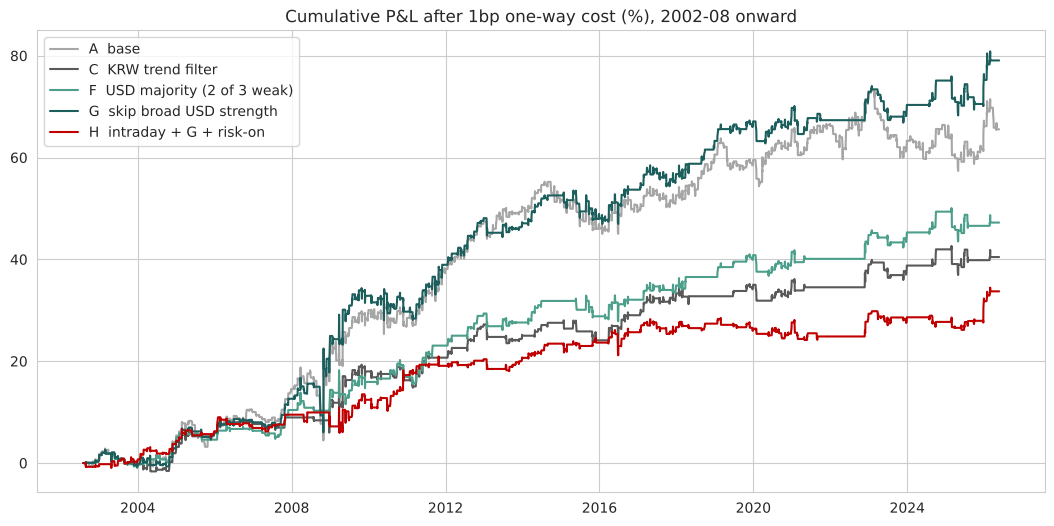

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
labels2 = ["A  base", "C  KRW trend filter", "F  USD majority (2 of 3 weak)", "G  skip broad USD strength", "H  intraday + G + risk-on"]
for (name, (daily, _)), label, color in zip(runs2.items(), labels2, [GRAY, "#595959", SUB, MAIN, RED]):
    ax.plot(daily.index, ((1 + daily["pnl"]).cumprod() - 1) * 100, label=label, color=color, linewidth=1.5)
ax.set_title("Cumulative P&L after 1bp one-way cost (%), 2002-08 onward")
ax.legend()
plt.show()

- F와 G 모두 원화만 본 C보다 낫다. Sharpe는 A 0.44, C 0.49, F 0.58, G 0.55다.
- G는 거래를 204회 유지하면서 MDD를 -12%에서 -9%로 줄이고, F는 거래가 절반이지만 MDD가 -6%다.
- 2014년 이후만 보면 A는 거래당 +0.07%(t 0.9)로 사라진 반면 G는 +0.22%(t 2.2), F는 +0.24%(t 1.9)다. 4장에서 2013년 이후 약해졌다고 본 것의 상당 부분이 달러 강세 국면 때문이었다.
- 장중 전략 H는 비용 전 Sharpe가 0.72로 가장 높지만 편도 2bp에서 0.21로 떨어진다.

주의할 점. 변수와 기준을 전체 표본을 보고 골랐으므로 2014년 이후가 엄밀한 표본 외 검증은 아니다. 조건을 15개쯤 시험했으니 p 0.02~0.03 수준의 결과 한두 개는 우연일 수 있다. p 0.01 아래로 남는 것은 USD/JPY 조건과 '셋 다 강세' 조건이다.

## 정리

| 가설 | 판정 | 근거 |
|---|---|---|
| H1 장중에만 나타난다 | 채택 | 장중 +0.19% (t 3.8), 야간 -0.01% |
| H2 거래량이 늘어난다 | 부분 지지 | 월말 당일만 +7% (t 3.3) |
| H3 환율 하락 국면에서 강하다 | 부분 지지 | 장중 승률 67% 대 55% (p 0.03) |
| H4 원화 금리 우위일 때 강하다 | 부분 지지 | 장중 승률 66% 대 55% (p 0.03), 평균 차이는 없음 |
| H5 분기말에 강하다 | 기각 | 차이 없음 |
| H6 저변동성일 때 강하다 | 기각 | 차이 없음 |
| G0 글로벌 요인과 별개다 | 채택 | 통제 후에도 월말 더미 -0.045% (t -3.6) |
| G1 글로벌 달러 약세 국면에서 강하다 | 채택 | USD/JPY 조건 +0.41% 대 +0.02% (p 0.006), 세 기간 일치 |
| G2 위험선호 국면에서 강하다 | 부분 지지 | 장중만 유의 (p 0.02), 종가 기준은 차이 없음 |
| G3 한미 금리차 | 기각 | 방향만 일치 |
| G4 미국 금리 방향 | 기각 | 차이 없음 |
| G5 유가 | 기각 | 가설과 반대 방향 |

월말 네고 효과는 글로벌 요인과 별개로 서울 장중에 나타나고, 달러가 전방위로 강한 국면에서만 사라진다. 그 국면을 피하는 것만으로 2014년 이후에도 유의한 성과가 남는다.

남은 문제.

- 조건을 사후에 골랐다. 새 자료가 쌓이는 대로 같은 규칙을 그대로 적용해 확인해야 한다.
- 네고 물량 자체를 본 것이 아니다. 거주자 외화예금이나 수출입 통계로 직접 확인하는 것이 다음 단계다.
- 장중 전략은 체결 비용이 전부다. 시간대별 자료가 있어야 진입 시점을 좁힐 수 있다.